In [1]:
import kagglehub
path = kagglehub.dataset_download("balraj98/duts-saliency-detection-dataset")

Using Colab cache for faster access to the 'duts-saliency-detection-dataset' dataset.


In [2]:
import os
print(os.listdir(path))

['DUTS-TE', 'metadata.csv', 'DUTS-TR']


In [3]:
%cd Projekti3_ML_DL/


/content/Projekti3_ML_DL


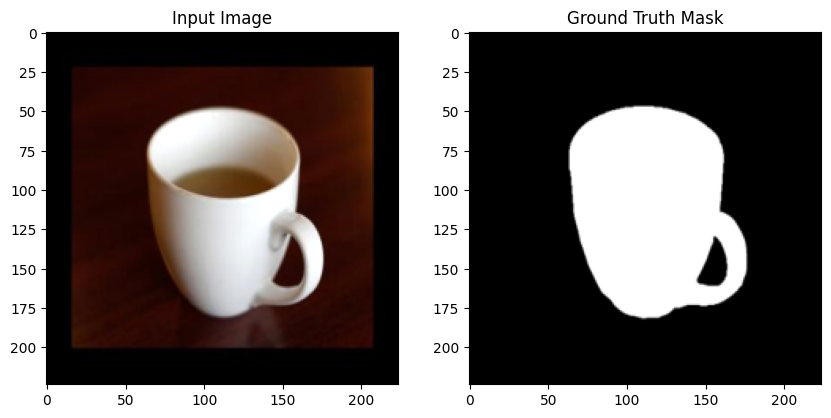

In [4]:
from data_loader import get_loader
import matplotlib.pyplot as plt

train_img_path = os.path.join(path, 'DUTS-TR', 'DUTS-TR-Image')
train_mask_path = os.path.join(path, 'DUTS-TR', 'DUTS-TR-Mask')

test_img_path = os.path.join(path, 'DUTS-TE', 'DUTS-TE-Image')
test_mask_path = os.path.join(path, 'DUTS-TE', 'DUTS-TE-Mask')

train_loader = get_loader(train_img_path, train_mask_path, batch_size=4)

images, masks = next(iter(train_loader))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Input Image")
plt.imshow(images[0].permute(1, 2, 0))
plt.subplot(1, 2, 2)
plt.title("Ground Truth Mask")
plt.imshow(masks[0].squeeze(), cmap='gray')
plt.show()

In [5]:
from sod_model import SODModel

model = SODModel()
output = model(images)

print(f"Input shape: {images.shape}")
print(f"Output shape: {output.shape}")

Input shape: torch.Size([4, 3, 224, 224])
Output shape: torch.Size([4, 1, 224, 224])


In [6]:
from train import train_model
from data_loader import get_loader
from sod_model import SODModel
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_loader = get_loader(train_img_path, train_mask_path, batch_size=16)
val_loader = get_loader(test_img_path, test_mask_path, batch_size=16)

model = SODModel().to(device)

train_model(model, train_loader, val_loader, epochs=20, device=device)

Epoch [1/20] - Train Loss: 0.8798, Val Loss: 0.8380
Best model saved!
Epoch [2/20] - Train Loss: 0.8436, Val Loss: 0.9157
Epoch [3/20] - Train Loss: 0.8293, Val Loss: 0.8488
Epoch [4/20] - Train Loss: 0.8184, Val Loss: 0.8422
Epoch [5/20] - Train Loss: 0.8118, Val Loss: 0.8136
Best model saved!
Epoch [6/20] - Train Loss: 0.8055, Val Loss: 0.8132
Best model saved!
Epoch [7/20] - Train Loss: 0.7983, Val Loss: 0.7907
Best model saved!
Epoch [8/20] - Train Loss: 0.7942, Val Loss: 0.8241
Epoch [9/20] - Train Loss: 0.7918, Val Loss: 0.7902
Best model saved!
Epoch [10/20] - Train Loss: 0.7861, Val Loss: 0.7703
Best model saved!
Epoch [11/20] - Train Loss: 0.7823, Val Loss: 0.7724
Epoch [12/20] - Train Loss: 0.7789, Val Loss: 0.7929
Epoch [13/20] - Train Loss: 0.7758, Val Loss: 0.7788
Epoch [14/20] - Train Loss: 0.7715, Val Loss: 0.7501
Best model saved!
Epoch [15/20] - Train Loss: 0.7694, Val Loss: 0.8434
Epoch [16/20] - Train Loss: 0.7664, Val Loss: 0.8022
Epoch [17/20] - Train Loss: 0.7651,

In [8]:
from evaluate import evaluate_model

checkpoint = torch.load('best_sod_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])

evaluate_model(model, val_loader, device)

Final Metrics:
IoU: 0.3061
Precision: 0.4355
Recall: 0.5165
F1-Score: 0.4658


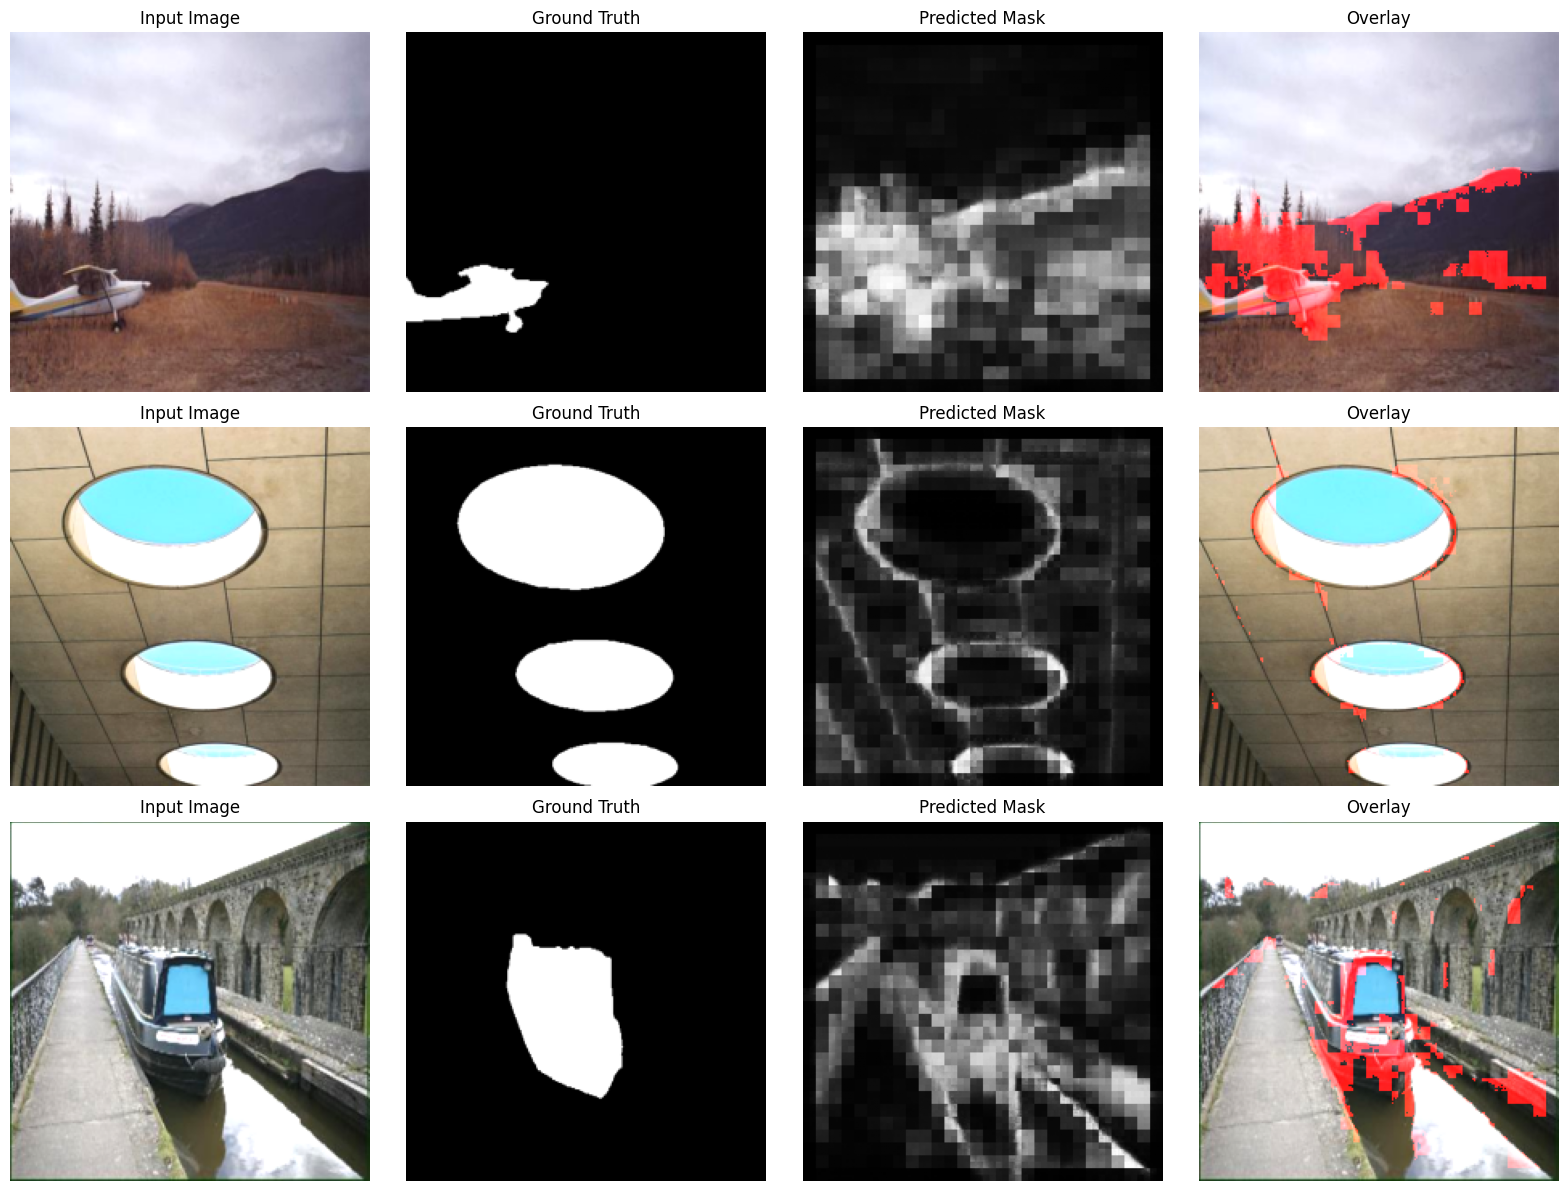

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

def visualize_results(model, loader, device, num_samples=3):
    model.eval()
    images, masks = next(iter(loader))
    images, masks = images.to(device), masks.to(device)

    with torch.no_grad():
        preds = model(images)

    plt.figure(figsize=(16, 4 * num_samples))

    for i in range(num_samples):
        # Input Image
        plt.subplot(num_samples, 4, i*4 + 1)
        plt.imshow(images[i].cpu().permute(1, 2, 0))
        plt.title("Input Image")
        plt.axis('off')

        # Ground Truth Mask
        plt.subplot(num_samples, 4, i*4 + 2)
        plt.imshow(masks[i].cpu().squeeze(), cmap='gray')
        plt.title("Ground Truth")
        plt.axis('off')

        # Predicted Saliency Mask
        plt.subplot(num_samples, 4, i*4 + 3)
        plt.imshow(preds[i].cpu().squeeze(), cmap='gray')
        plt.title("Predicted Mask")
        plt.axis('off')

        # 4. Overlay
        plt.subplot(num_samples, 4, i*4 + 4)
        img_np = images[i].cpu().permute(1, 2, 0).numpy()
        mask_np = preds[i].cpu().squeeze().numpy()
        overlay = img_np.copy()
        overlay[:, :, 0] = np.where(mask_np > 0.5, 1.0, overlay[:, :, 0])

        plt.imshow(overlay)
        plt.title("Overlay")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

visualize_results(model, val_loader, device)